# Is control-calibrated DiMeLo-seq a valid genome-wide CTCF binding assay?

DiMeLo-seq targets a factor (here CTCF) with a protein-A–Hia5 fusion that deposits **6mA on DNA near
the antibody-bound protein**. A negative control (free pA-Hia5, no targeting antibody) lets us build a
per-read background null and call **control-calibrated occupancy**. This notebook asks three things and
answers them against two orthogonal truths (ENCODE CTCF ChIP-seq and GM12878 CTCF **CUT&RUN**):

1. **Does control-calibrated occupancy quantify CTCF binding genome-wide?**
2. **What kind of assay is DiMeLo — does it behave like CUT&RUN or like ChIP?**
3. **Can we detect binding sites *de novo*, and how does that compare to `modkit dmr`?**

### TL;DR — what we learned
- **It works as a binding quantifier.** Occupancy tracks CUT&RUN at ρ≈0.68 (AUROC≈0.84), monotonically,
  and **independent of sequencing depth** (raw coverage only ρ≈0.30). Robust across metrics and truths.
- **Soft ≫ hard.** Binary FDR calls undercount and sit at the coverage baseline; the soft/Bayesian
  occupancy estimators nearly double the correlation. The Bayesian posterior (with a credible interval)
  is the most defensible *absolute* occupancy number.
- **DiMeLo behaves like CUT&RUN, not ChIP.** Its signal correlates with CUT&RUN ≈ as well as CUT&RUN
  correlates with ChIP, and ~2× better than DiMeLo↔ChIP — expected, since DiMeLo and CUT&RUN share the
  antibody-tethered-enzyme *in situ* mechanism while ChIP is crosslink+IP.
- **modkit dmr: right score, wrong segmenter.** Its continuous `effect_size` is the single best ranker;
  but its HMM `--segment` (built for bimodal 5mC) flags **0 differential regions genome-wide** for
  DiMeLo's graded 6mA.
- **De novo detection works** — a control-calibrated peak-caller finds CTCF sites with no prior site
  list at up to **94% precision (11× enrichment)**, recovering **65% of stringent CUT&RUN sites**;
  novel calls are CTCF-motif- and CUT&RUN-signal-enriched. This is exactly the signal modkit's HMM missed.


---
# Part 1 · What we measure

**Data.** One-pot GM12878 experiment, chm13v2.0. `barcode17` = CTCF-targeted, `barcode18` = free-pA
negative control.

**Estimators compared** (all per-site, from the same per-read evidence):
`hard rate` (binary FDR) · `posterior mean` (soft 2-component) · `MLE` / `recal` (per-site mixing
weight) · `Bayesian mean` (full posterior + 95% CrI) · `ensemble effect` (control-subtracted 6mA =
the `modkit dmr` metric).

## 1.1 How are the analysis regions defined?

In [1]:
import json, pandas as pd
from pathlib import Path
from IPython.display import Image, display
A = Path("artifacts/genomewide"); dn = Path("artifacts/denovo"); tw = Path("artifacts/threeway")
print(json.dumps(json.loads((A/"region_def.json").read_text()), indent=2))

{
  "n_regions": 18803,
  "region_width_bp": 4000,
  "all_same_width": true,
  "n_chromosomes": 24,
  "occupancy_subwindow_bp": "central +/-150 (300bp) around region center",
  "regions_with_encode_ctcf_peak": 13328,
  "frac_with_encode_ctcf_peak": 0.709,
  "regions_with_jaspar_ma0139_motif": 112,
  "frac_with_jaspar_motif": 0.006,
  "regions_with_encode_summit_within_100bp_of_center": 8598,
  "encode_summit_offset_within_region": {
    "median": 1990,
    "p10": 969,
    "p90": 3058,
    "n_summits_in_regions": 34690
  },
  "n_jaspar_motifs_total": 23375
}


**18,803 fixed 4 kb windows**, each centered on a candidate CTCF locus: the ENCODE peak *summit*
sits at a median offset of 1,990 bp (dead-center), and 71% of windows contain an ENCODE CTCF peak.
Per-read occupancy evidence `(k = 6mA count, n = valid A)` is counted over the **central ±150 bp**.

> **Caveat that shapes the whole analysis:** because the windows are CTCF-candidate loci by
> construction, ENCODE overlap is partly built in. So the region-level task is *"among CTCF-candidate
> windows, which are actually bound"* — CUT&RUN (which did not inform region selection) is the more
> honest truth, and de novo detection (Part 4) removes the region set entirely.

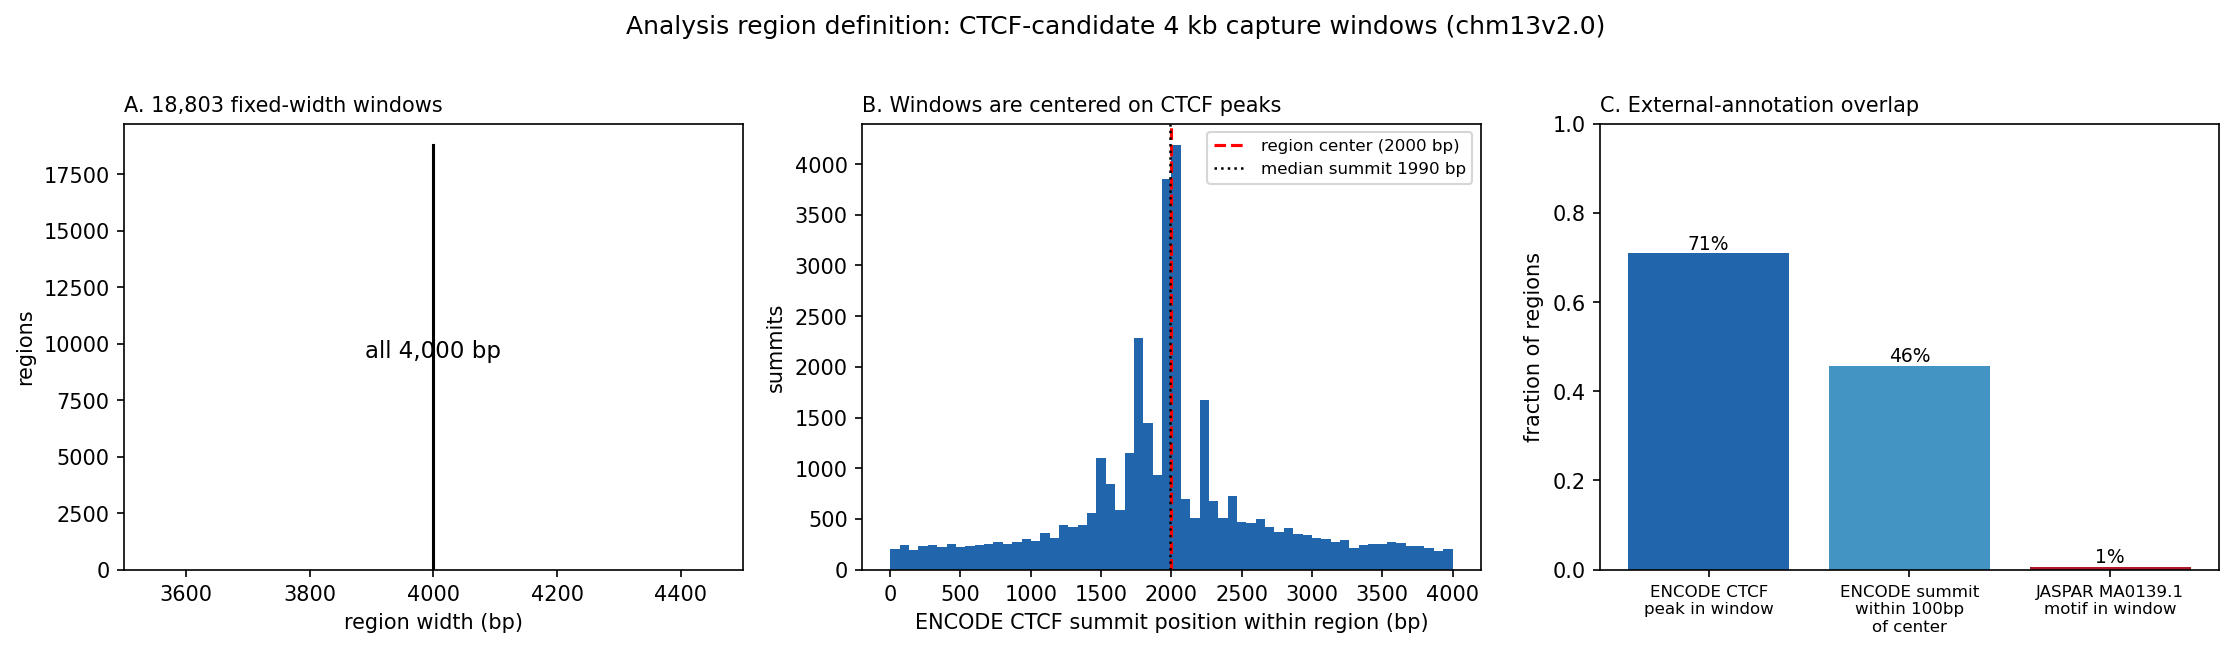

In [2]:
display(Image(str(A/"fig_region_definition.png")))

---
# Part 2 · Does control-calibrated occupancy quantify binding?

## 2.1 Validation against CUT&RUN (the cleaner orthogonal truth)

n sites: 13167 | ENCODE-overlap fraction: 0.68
truth agreement (ENCODE ChIP <-> CUT&RUN): {'spearman_encode_signal_vs_cutrun': 0.503, 'cutrun_depth_at_encode_overlap': 0.9, 'cutrun_depth_at_encode_nonoverlap': 0.1}


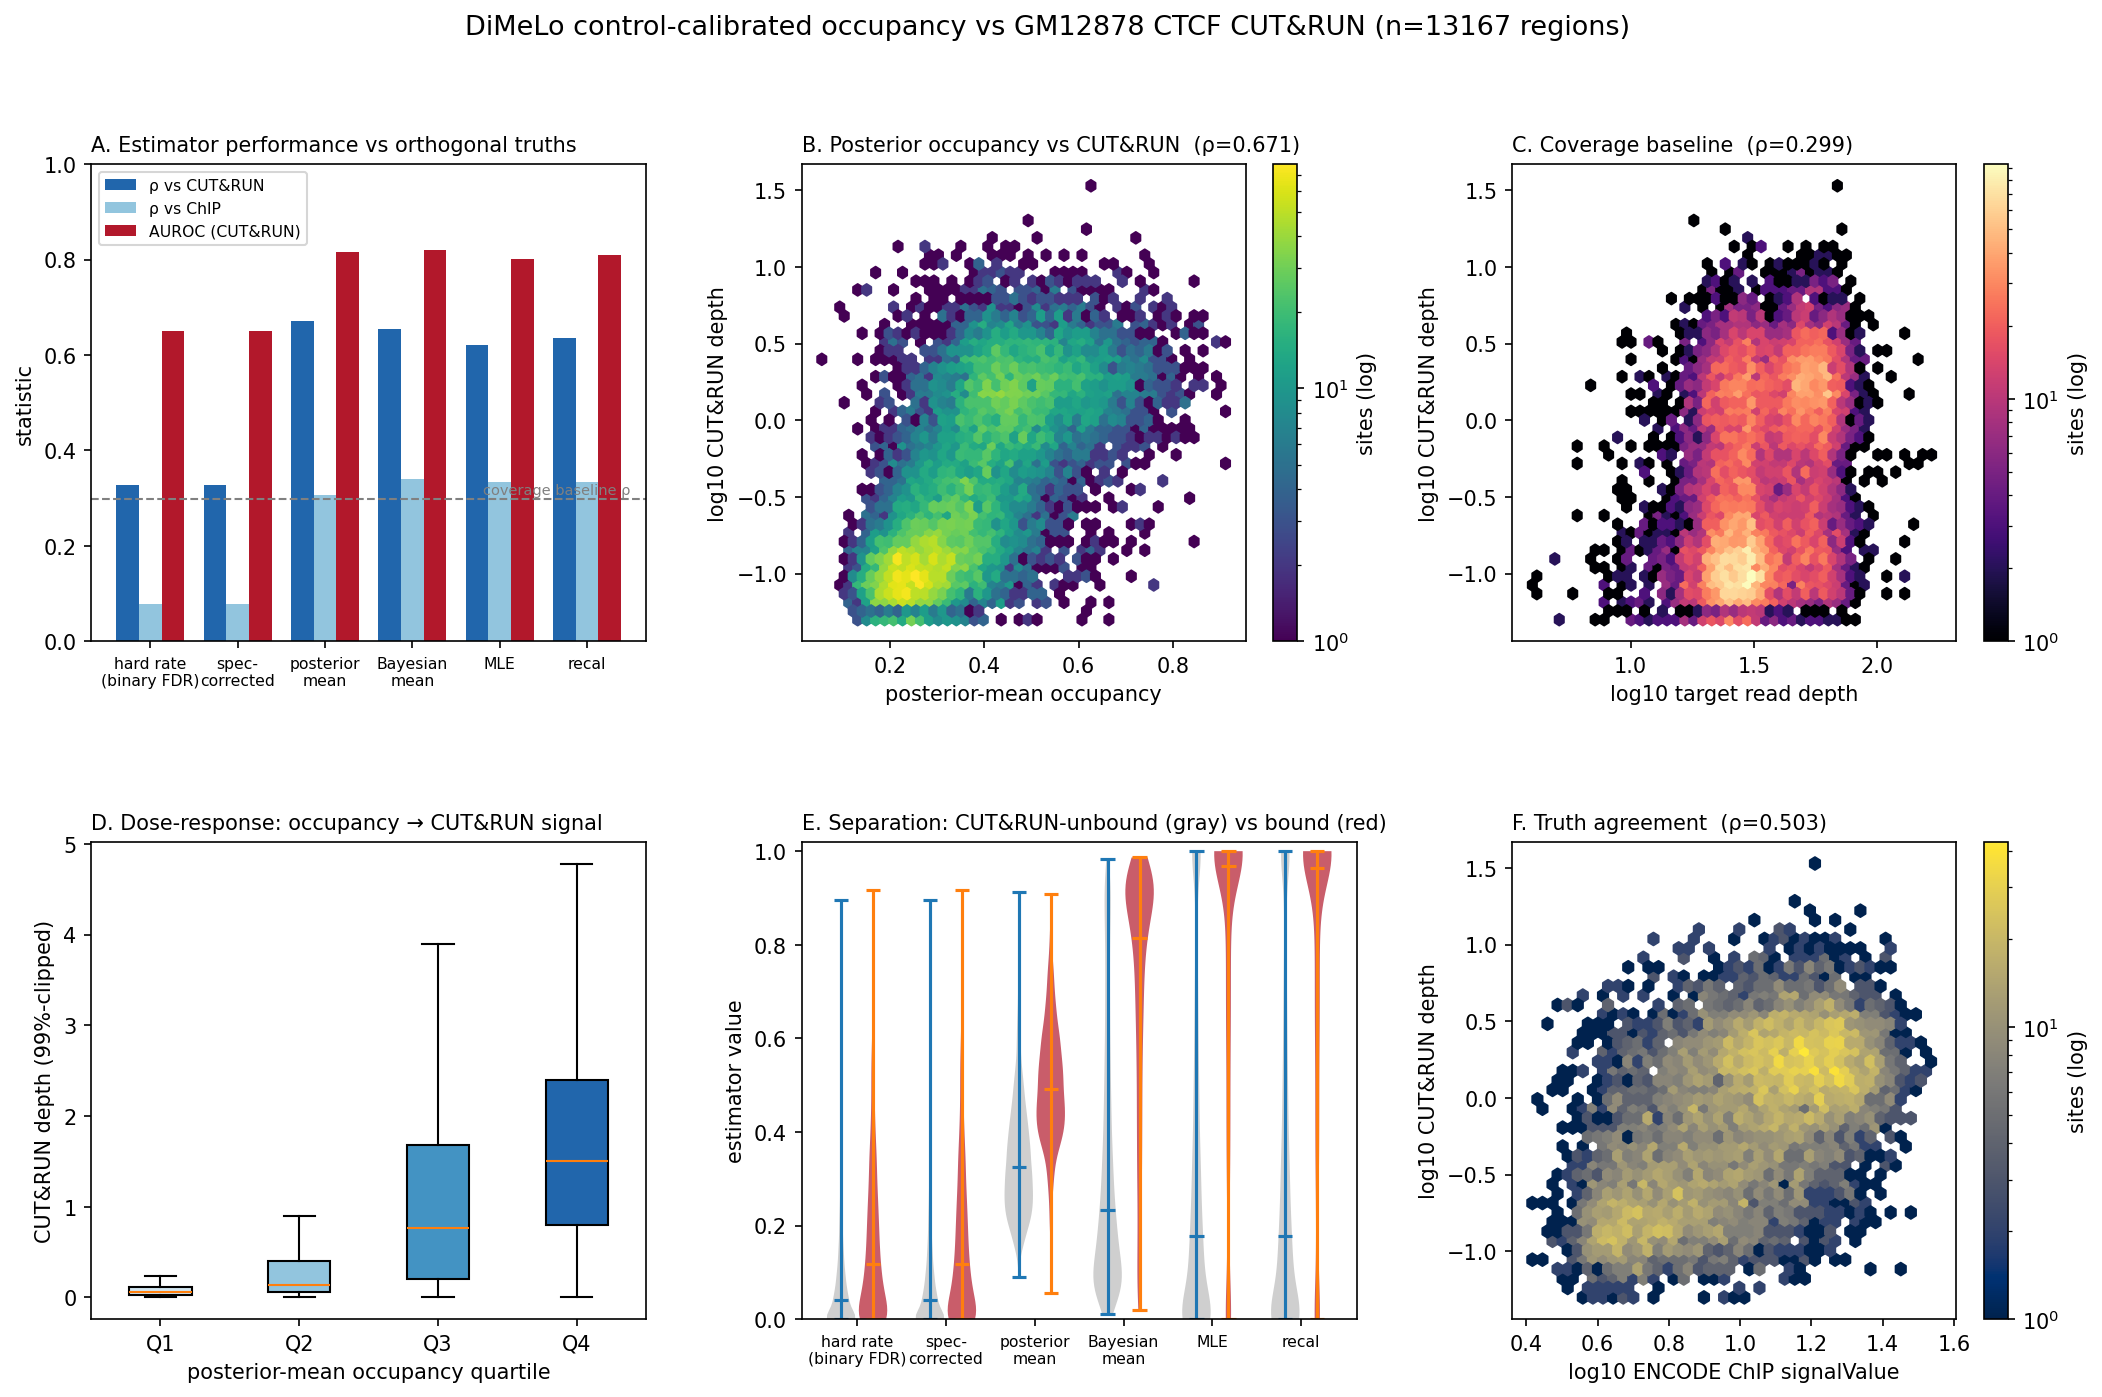

In [3]:
cv = json.loads((A/"cutrun_validate.json").read_text())
print("n sites:", cv["n_sites"], "| ENCODE-overlap fraction:", cv["encode_overlap_frac"])
print("truth agreement (ENCODE ChIP <-> CUT&RUN):", cv["truth_agreement"])
display(Image(str(A/"fig_cutrun_validation.png")))

(A) soft estimators clear the coverage baseline; hard rate sits on it. (B) occupancy tracks CUT&RUN
depth (ρ=0.67); (C) raw read depth does **not** (ρ=0.30) — the signal is occupancy, not coverage.
(D) monotonic dose-response. (E) MLE/recal/Bayesian separate bound/unbound cleanly. (F) the two truths
agree at ρ=0.50 — ChIP is the noisier truth and the ceiling.

## 2.2 Full genome-wide synthesis (all 24 chromosomes, all estimators)

In [4]:
ee = json.loads((A/"ensemble_effect.json").read_text())
display(pd.DataFrame(ee["table"]).set_index("estimator"))
print("modkit cross-check — H5 ensemble_effect vs native modkit dmr_effect (chr1-12):",
      ee["modkit_crosscheck"])

,n,rho_CUTRUN,pearson_CUTRUN,pearsonlog_CUTRUN,auroc_CUTRUN,auroc_ENCODE,rho_ChIP
estimator,,,,,,,
hard_rate,13167,0.328,0.237,0.333,0.650,0.646,0.078
occupancy_posterior_mean,13167,0.671,0.447,0.646,0.816,0.846,0.306
occ_bayes_mean,13167,0.655,0.474,0.673,0.819,0.826,0.341
occ_mle,13167,0.621,0.461,0.653,0.802,0.801,0.333
occ_recal,13167,0.635,0.462,0.654,0.809,0.813,0.334
ensemble_effect,13167,0.681,0.496,0.613,0.840,0.820,0.373


modkit cross-check — H5 ensemble_effect vs native modkit dmr_effect (chr1-12): {'n_subset': 12464, 'spearman_ensemble_vs_modkit_effect': 0.704, 'pearson_ensemble_vs_modkit_effect': 0.627}


**`ensemble_effect` (control-subtracted 6mA) is the best single ranker** (ρ=0.68 CUT&RUN,
AUROC 0.84, best ChIP too) — this is exactly modkit dmr's `effect_size`, computed genome-wide from the
H5 (cross-checks to modkit at ρ=0.70). **Bayesian occupancy is within ~0.03 ρ** while additionally
giving per-molecule states, uncertainty, and footprints. **Hard binary FDR undercounts** and sits at
the coverage baseline.

## 2.3 Is the ranking an artifact of the metric? (Pearson vs Spearman)

In [5]:
display(pd.read_csv(A/"pearson_vs_spearman.csv"))

,estimator,spearman_CUTRUN,pearson_CUTRUN,pearson_log_CUTRUN,spearman_ChIP,pearson_ChIP,pearson_log_ChIP
0,hard_rate,0.328,0.237,0.333,0.078,0.071,0.087
1,occ_spec_corrected,0.328,0.237,0.333,0.078,0.071,0.087
2,occupancy_posterior_mean,0.671,0.447,0.646,0.306,0.259,0.290
3,occ_bayes_mean,0.655,0.474,0.673,0.341,0.318,0.349
4,occ_mle,0.621,0.461,0.653,0.333,0.312,0.342
5,occ_recal,0.635,0.462,0.654,0.334,0.312,0.342


No. Spearman > Pearson(raw) uniformly because CUT&RUN depth is heavy-tailed and occupancy
saturates at 1.0 (monotonic but non-linear); log-transforming depth closes the gap (Pearson-log ≈
Spearman). The effect is real and identical under all three metrics — and the *ordering* of estimators
is the same under ENCODE and CUT&RUN. **Conclusion: validated as a relative/ranking binding quantifier,
depth-independent, metric- and truth-robust.**

---
# Part 3 · What kind of assay is DiMeLo — CUT&RUN or ChIP?

DiMeLo (pA-Hia5) and CUT&RUN (pA-MNase) are the **same class of assay** — an antibody-tethered enzyme
acting on nearby DNA *in situ*. ChIP is crosslink + immunoprecipitation. So we expect DiMeLo's readout
to resemble CUT&RUN more than ChIP.

overall ENCODE recovery: {'dimelo': 0.325, 'cutrun': 0.069}
median ENCODE ChIP signal of captured peaks: {'all_encode': 4.14, 'captured_by_dimelo': 4.88, 'captured_by_cutrun': 6.22}
signal similarity at shared sites (Spearman, n=8,951): {'DiMeLo-CUT&RUN': 0.507, 'DiMeLo-ChIP': 0.306, 'CUT&RUN-ChIP': 0.503}


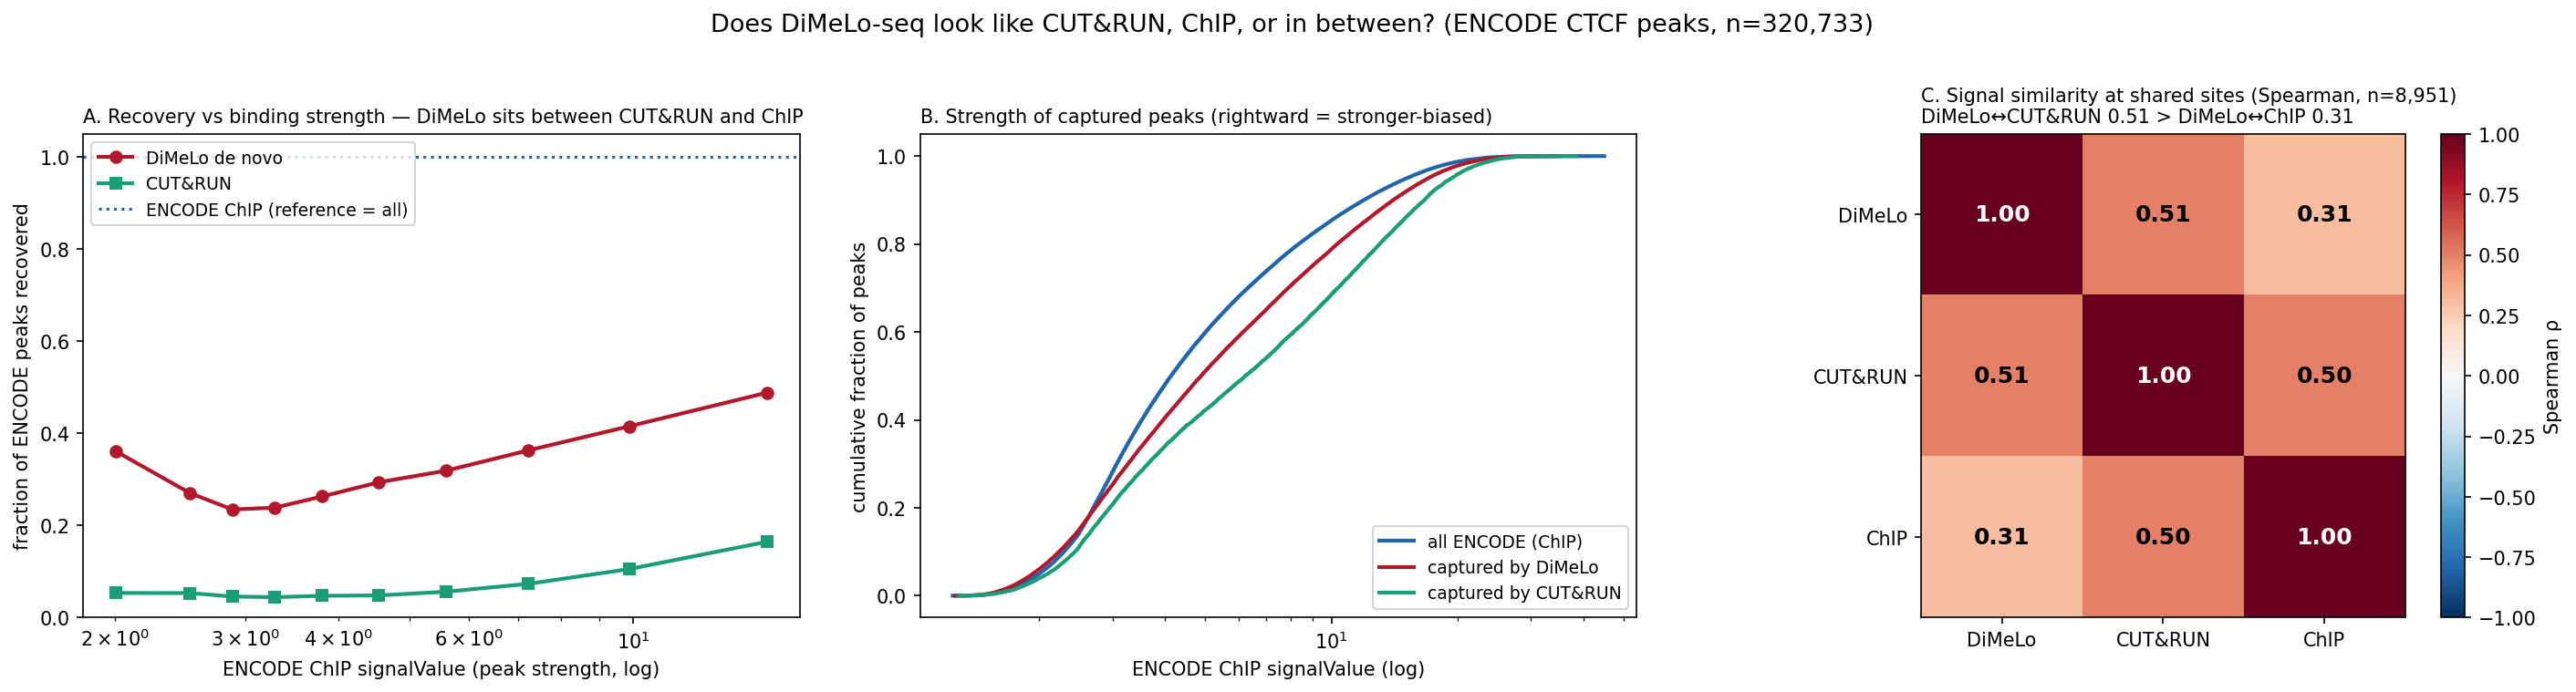

In [6]:
asp = json.loads((tw/"assay_spectrum.json").read_text())
print("overall ENCODE recovery:", asp["overall_recovery"])
print("median ENCODE ChIP signal of captured peaks:", asp["median_encode_signal"])
print(f"signal similarity at shared sites (Spearman, n={asp['assay_signal_spearman_n']:,}):",
      asp["assay_signal_spearman"])
display(Image(str(tw/"fig_assay_spectrum.png")))

**Readout (panel C, the threshold-free test):** DiMeLo↔CUT&RUN ≈ 0.51 vs DiMeLo↔ChIP ≈ 0.31, and
DiMeLo↔CUT&RUN essentially equals the CUT&RUN↔ChIP agreement (0.50) — over the full region set
DiMeLo↔CUT&RUN rises to 0.67. **DiMeLo reproduces CUT&RUN's signal as well as the two established
assays reproduce each other, and far better than ChIP** — exactly as the shared proximity-labeling
mechanism predicts. **Detection breadth (A,B):** DiMeLo sits *between* CUT&RUN and ChIP (recovers 33%
of ENCODE vs CUT&RUN's 7%; captures a less strength-biased set than CUT&RUN). The breadth axis depends
on peak-calling stringency; the signal correlation (C) is the fair measure and places DiMeLo with
CUT&RUN.

---
# Part 4 · How does `modkit dmr` compare?

`modkit dmr` is the standard tool for differential methylation. It offers a continuous per-region
**score/effect_size** and an HMM **`--segment`** mode (2-state Same/Different) — the latter being its
built-in de novo caller.

## 4.1 Native modkit dmr on shared sites (chr1–12 subset, 12,464 regions)

In [7]:
display(pd.read_csv(A/"synth_subset.csv").set_index("estimator"))

,rho_CUTRUN,pearson_CUTRUN,pearsonlog_CUTRUN,auroc_CUTRUN,auroc_ENCODE,rho_ChIP
estimator,,,,,,
hard_rate,0.283,0.201,0.293,0.621,0.636,0.042
occ_spec_corrected,0.283,0.201,0.293,0.621,0.636,0.042
occupancy_posterior_mean,0.630,0.416,0.608,0.781,0.837,0.289
occ_bayes_mean,0.633,0.452,0.645,0.793,0.823,0.343
occ_mle,0.611,0.442,0.629,0.781,0.805,0.346
occ_recal,0.618,0.443,0.630,0.786,0.814,0.343
dmr_score,0.580,0.421,0.524,0.782,0.750,0.223
dmr_effect,0.698,0.537,0.667,0.840,0.823,0.331
dmr_cohen_h,0.638,0.467,0.617,0.809,0.785,0.262


On the identical region set, **`dmr_effect` (effect_size) is the best ranker** (ρ=0.70, AUROC 0.84)
— tied with our single-molecule occupancy. But **modkit's default `score` is the *weakest* dmr readout**
(ρ=0.58): it folds in statistical *significance*, which for ranking binding *magnitude* just adds
coverage-driven noise. **Use `effect_size`, not the headline score.**

## 4.2 modkit's HMM segmentation is blind to DiMeLo 6mA (genome-wide)

Run genome-wide (all 24 chromosomes, deep-WGS target), `modkit dmr pair --segment` produced
**0 "Different" segments**. Retuning on the subset (`--fine-grained`, `--dmr-prior 0.3/0.5`) gave 0, 0,
and 2 (the 2 being tiny extreme-coverage outliers). modkit's HMM "Different" state is tuned for bimodal
5mC (0→80% swings); DiMeLo's real but **graded, low-level** 6mA enrichment (e.g. 2.5%→5%) never clears
its threshold. **So modkit's continuous effect captures DiMeLo occupancy; its HMM segmenter does not** —
which is why de novo detection needs a different approach.

---
# Part 5 · De novo CTCF detection (no prior site list)

Since modkit's HMM can't segment DiMeLo's graded 6mA, we build a peak-caller directly on the
**validated control-calibrated signal** (target − control 6mA enrichment):

1. genome-wide per-base 6mA pileups for target + control (≥5× coverage);
2. tile the genome into **200 bp windows**;
3. per window, sum target/control (methylated, valid) A-counts (≥20 valid each);
4. **one-sided two-proportion z-test** for target 6mA > control, **BH-FDR** across all windows;
5. call windows at **q < 0.05 and effect ≥ threshold** (the tunable biological knob);
6. **merge** adjacent significant windows → de novo peaks.

Same signal as modkit's `effect_size` (ρ=0.70 between them); the difference is a powered statistical
test + explicit effect floor instead of modkit's 5mC-tuned HMM.

```mermaid
flowchart TD
    T0["Target BAM<br/>barcode17 · CTCF-pA-Hia5"] --> P1["modkit pileup<br/>per-base 6mA · 24 chr"]
    C0["Control BAM<br/>barcode18 · free pA-Hia5"] --> P2["modkit pileup<br/>per-base 6mA · 24 chr"]
    P1 --> F1["keep positions<br/>Nvalid ≥ 5"]
    P2 --> F2["keep positions<br/>Nvalid ≥ 5"]
    F1 --> W["Tile genome into<br/>200 bp windows"]
    F2 --> W
    W --> S["Per window: sum target &amp; control<br/>methylated + valid A-counts<br/>(require ≥ 20 valid each)"]
    S --> Z["One-sided two-proportion z-test<br/>target 6mA fraction &gt; control"]
    Z --> BH["Benjamini–Hochberg FDR<br/>across all windows"]
    BH --> D{"q &lt; 0.05<br/>AND effect ≥ threshold"}
    D -->|no| X["discard"]
    D -->|yes| MG["Merge adjacent<br/>significant windows"]
    MG --> PK["De novo CTCF peaks"]
    PK --> V["Validate (no site list):<br/>ENCODE ChIP · CUT&amp;RUN · JASPAR motif"]

    classDef data fill:#e8eef7,stroke:#2166ac;
    classDef test fill:#fdece8,stroke:#b2182b;
    classDef out fill:#e7f3ec,stroke:#1b9e77;
    class T0,C0,P1,P2,F1,F2 data;
    class W,S,Z,BH,D,MG test;
    class PK,V out;
```
*The effect-size threshold on the `q < 0.05 AND effect ≥ threshold` gate is the single biological knob
(Part 5.1); it replaces modkit's 5mC-tuned HMM, which is blind to this graded 6mA signal (Part 4.2).*

covered windows: 11,732,328 | de novo peaks: 83,952
ENCODE genome coverage: 0.073 | enrichment over shuffled: 11.25 x


,effect_thr,n_windows,n_peaks,precision,sensitivity
0,0.05,130734,83952,0.552,0.325
1,0.10,36835,26620,0.885,0.186
2,0.15,18454,14332,0.929,0.117
3,0.20,10219,8333,0.942,0.075
4,0.30,3201,2882,0.953,0.030
5,0.40,971,930,0.957,0.010


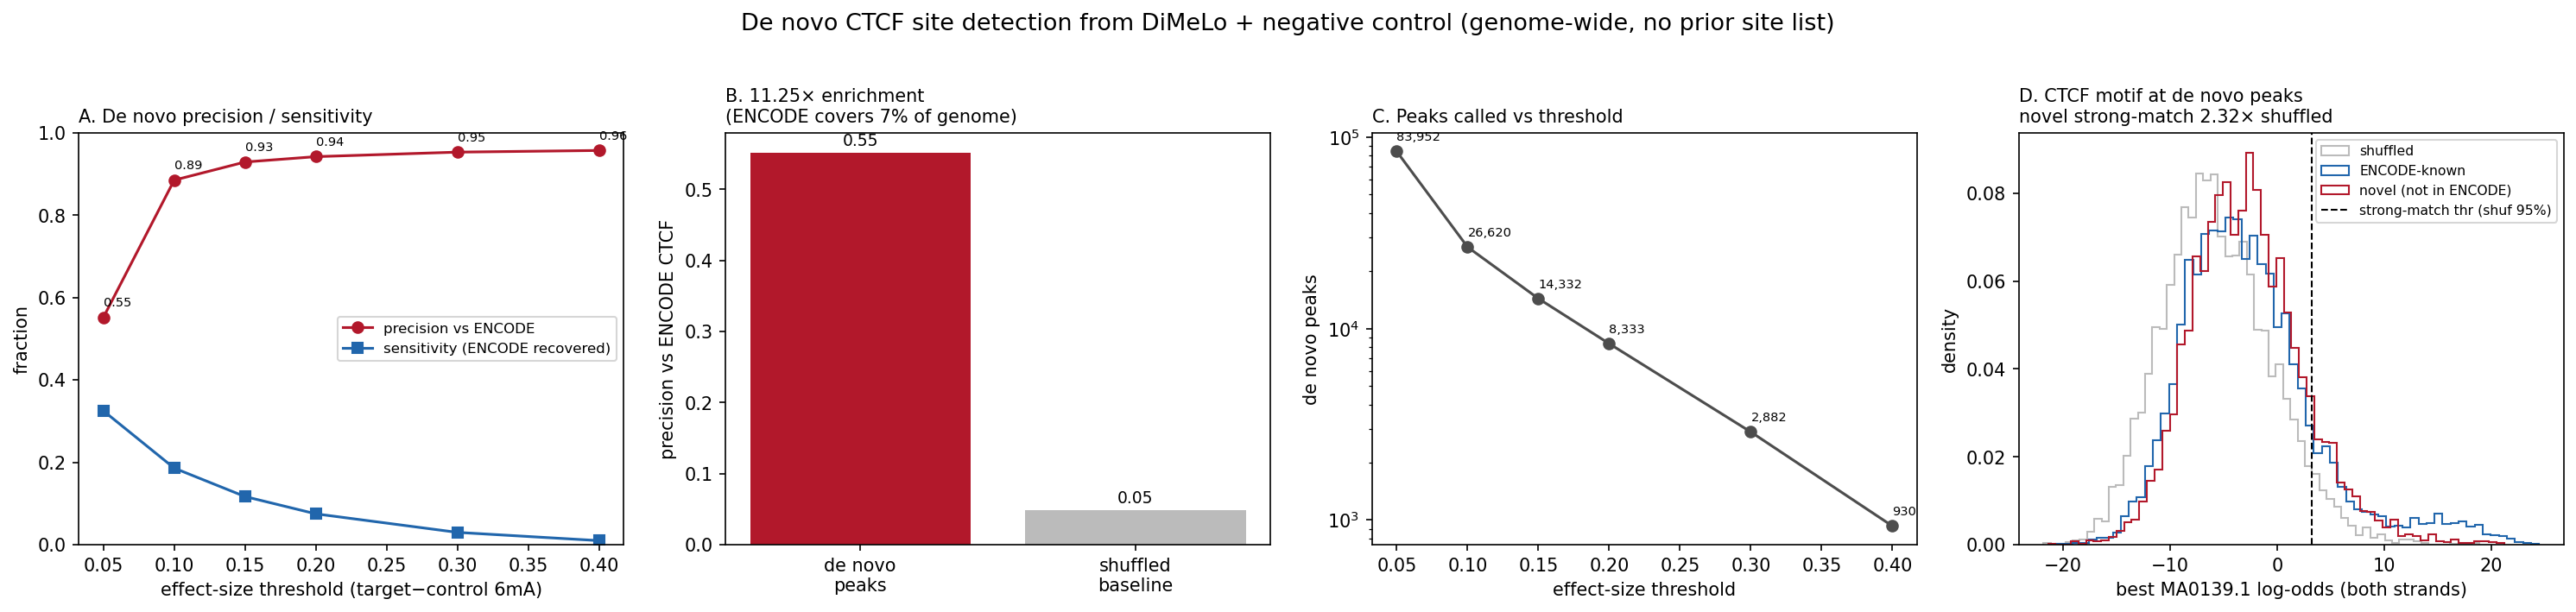

In [8]:
rep = json.loads((dn/"denovo_report.json").read_text())
ev  = json.loads((dn/"denovo_eval.json").read_text())
print("covered windows:", f"{rep['covered_windows']:,}", "| de novo peaks:", f"{rep['denovo_peaks']:,}")
print("ENCODE genome coverage:", ev['encode_genome_coverage_frac'], "| enrichment over shuffled:",
      ev['enrichment_fold'], "x")
display(pd.DataFrame(ev["precision_sensitivity_vs_effect"]))
display(Image(str(dn/"fig_denovo.png")))

**It works.** ENCODE CTCF covers ~7% of the genome (random overlap ≈5%), yet de novo peaks overlap
at 55% — **11× enrichment**. The effect-size threshold trades sensitivity for precision cleanly:
**~27k peaks at 88.5% precision at effect ≥ 0.10**, ~8k peaks at **94%** at ≥0.20. Novel (not-in-ENCODE)
peaks are **2.3× CTCF-motif-enriched** over shuffled (panel D) — genuine unannotated sites.

## 5.1 FDR vs recovery — the effect size, not FDR, is the knob

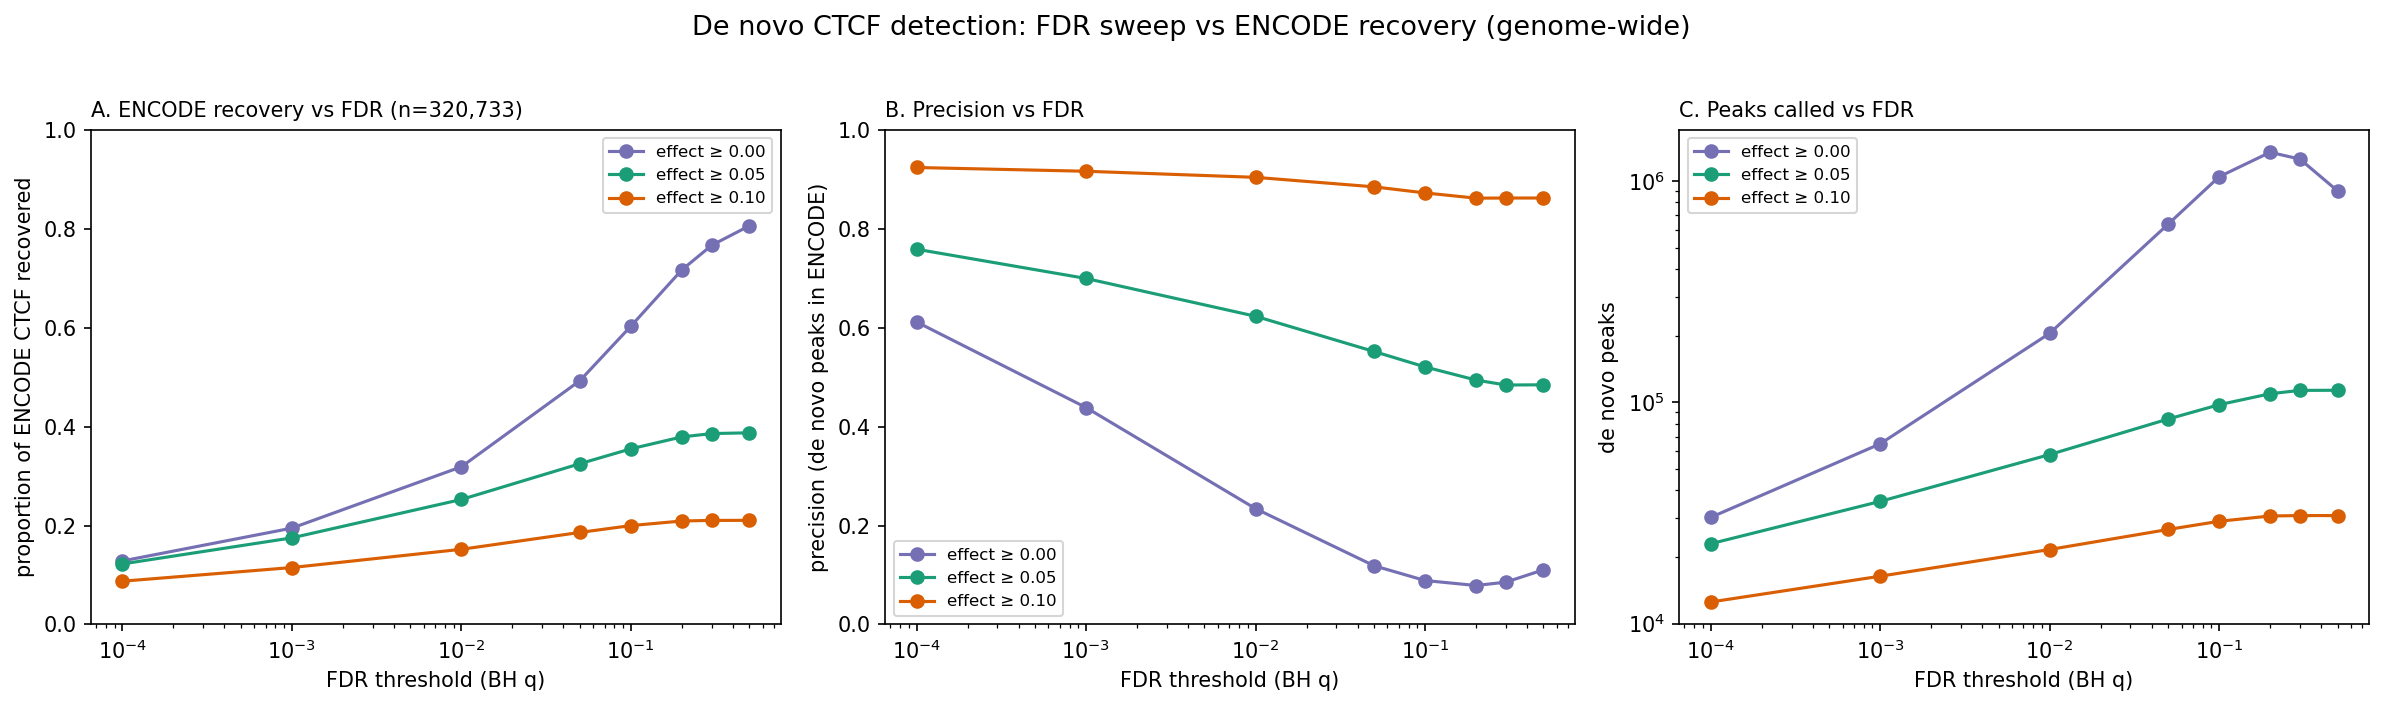

In [9]:
display(Image(str(dn/"fig_fdr_recovery.png")))

With deep-WGS coverage the two-proportion test is highly powered, so at a fixed effect floor
loosening FDR mostly adds sites while ENCODE recovery *saturates* — the **effect-size floor** sets both
precision and the recovery ceiling. (At effect ≥ 0 with loose FDR, a detectable signal exists at ~80%
of ENCODE peaks — an assay-coverage statement, not a usable operating point since precision is ~11%.)

## 5.2 Three-way concordance: DiMeLo de novo vs ENCODE vs CUT&RUN

peak counts: {'n_denovo': 83952, 'n_encode': 320733, 'n_cutrun_chm13': 11266}
de novo vs ENCODE: {'precision': 0.552, 'recovery': 0.325} | de novo vs CUT&RUN: {'precision': 0.085, 'recovery': 0.648}
truth agreement: {'encode_in_cutrun': 0.069, 'cutrun_in_encode': 0.951}
frac de novo peaks with CUT&RUN signal: {'denovo_known': 0.724, 'denovo_novel': 0.111, 'shuffled': 0.053} | novel enrichment: 2.1 x


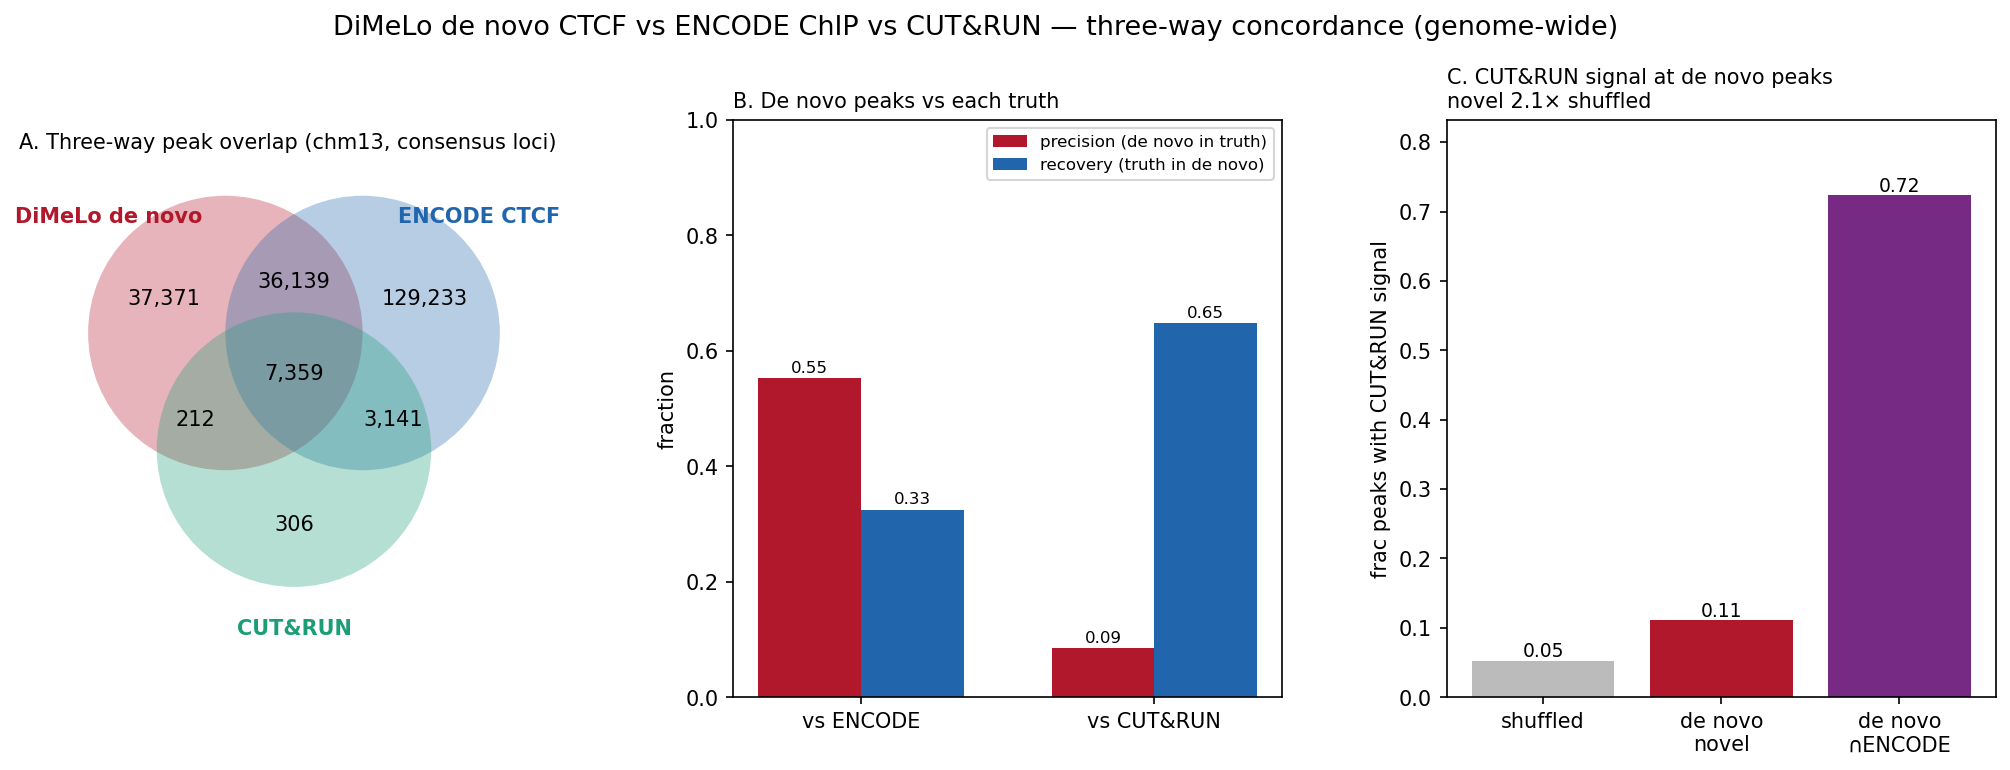

In [10]:
t3 = json.loads((tw/"threeway.json").read_text())
print("peak counts:", {k: t3[k] for k in ('n_denovo','n_encode','n_cutrun_chm13')})
print("de novo vs ENCODE:", t3["denovo_vs_encode"], "| de novo vs CUT&RUN:", t3["denovo_vs_cutrun"])
print("truth agreement:", t3["truth_agreement"])
print("frac de novo peaks with CUT&RUN signal:", t3["frac_with_cutrun_signal"],
      "| novel enrichment:", t3["novel_cutrun_enrichment_over_shuffled"], "x")
display(Image(str(tw/"fig_threeway.png")))

The three assays form a **confidence hierarchy**: CUT&RUN (~11k, stringent) ⊂ ENCODE (~321k,
permissive), with DiMeLo de novo (~84k) in between. **De novo recovers 65% of high-confidence CUT&RUN
sites vs 33% of permissive ENCODE** — expected, since CUT&RUN's peaks are the strongly-bound sites
DiMeLo finds preferentially. The low precision-vs-CUT&RUN (9%) is not a weakness — CUT&RUN is a tiny 11k
set, so most of DiMeLo's real calls are weaker sites it doesn't contain (but ENCODE does). **7,359 loci
are agreed by all three.** Panel C: ENCODE-confirmed de novo peaks carry strong CUT&RUN signal; **novel
peaks carry CUT&RUN signal at 2.1× shuffled** — a real weak-CTCF tail below the ChIP/CUT&RUN detection
floor.

---
# Conclusions

1. **Control-calibrated DiMeLo occupancy is a valid genome-wide binding quantifier** — tracks CUT&RUN
   at ρ≈0.68 / AUROC≈0.84, monotonically and **independent of sequencing depth**; metric- and
   truth-robust.
2. **Soft ≫ hard.** Binary FDR undercounts (coverage baseline); soft/Bayesian estimators nearly double
   the correlation. The **Bayesian posterior + CrI is the best absolute occupancy** number.
3. **Best ranker = control-subtracted ensemble 6mA** (= modkit `effect_size`), marginally ahead of
   single-molecule Bayesian occupancy — but only the single-molecule route gives per-molecule states,
   uncertainty, and footprints.
4. **DiMeLo behaves like CUT&RUN, not ChIP** — its signal reproduces CUT&RUN as well as the two
   established assays reproduce each other (ρ≈0.5–0.67) and ~2× better than ChIP, matching the shared
   proximity-labeling mechanism.
5. **modkit dmr — right score, wrong segmenter.** `effect_size` is the best ranker; the default `score`
   is worse (significance ≠ magnitude); the HMM `--segment` flags **nothing** at DiMeLo 6mA scale.
6. **De novo detection works** — a control-calibrated two-proportion peak-caller recovers CTCF sites
   genome-wide at up to **94% precision (11× enrichment)**, tunable via one effect-size knob; recovers
   **65% of stringent CUT&RUN**; novel calls are motif- and CUT&RUN-signal-enriched. This is exactly the
   signal modkit's HMM missed.

**Bottom line.** For *"is it bound / how strongly, relative to other sites"* the method is validated
genome-wide — by ranking against orthogonal assays and by de novo detection. For *"what exact fraction
of molecules is bound"* the Bayesian posterior with its credible interval is the most defensible single
number. DiMeLo is, as designed, a proximity-labeling assay that reads out like CUT&RUN — and its
control-calibrated signal supports both quantification and de novo discovery that `modkit dmr`'s HMM
cannot.